# Notebook 2 - Making a test simulation to get used to the functions

If you want to get used to the functions loaded in the previous section, so you can test them here.

This section:

- Loads all the parameters from a very simple one-cell simulation folder taken from the GitHub repository of the PnET Succession Extension (in `StartingCalibrationTest/SimulationFiles/PnETGitHub_OneCellSim_v8`) into Python objects
- Writes all of these parameters from the Python objects back into LANDIS-II parameters files in `/tmp/TestScenarioPnET`, also copying the files that are not parsed (e.g. raster files) in the process.
- Runs the simulation (using the LANDIS-II installation that is inside this docker image)
- Parses the outputs of the simulation (the rasters made with PnEt Output extension and the `.csv` files made with the PnET Site Output extension)
- Plot the outputs

```{tip}
If you don't want to test these functions, simply go to the next notebook.
```

## Loading functions

In [1]:
from functionsForCalibration import *
import shutil

## Loading all of the parameters from the simple one-cell sim 

In [2]:
PnETGitHub_OneCellSim = parse_All_LANDIS_PnET_Files(r"./SimulationFiles/PnETGitHub_OneCellSim_v8")
print("\n\n\nHere is the content of the Python dictionnary containing all of the parsed parameters :\n\n" + str(PnETGitHub_OneCellSim))




Here is the content of the Python dictionnary containing all of the parsed parameters :

{'!Run_scenario.bat': './SimulationFiles/PnETGitHub_OneCellSim_v8/!Run_scenario.bat', '.ipynb_checkpoints': './SimulationFiles/PnETGitHub_OneCellSim_v8/.ipynb_checkpoints', 'biomass.outputPnET.txt': {'LandisData': '"Output-PnET"', 'Timestep': '10', 'Species': 'ALL', 'Wood-FoliageBiomass': 'output/WoodFoliageBiomass/{species}/WoodFoliageBiomass-{timestep}.img', 'WoodBiomass': 'output/WoodBiomass/{species}/WoodBiomass-{timestep}.img', 'FoliageBiomass': 'output/FoliageBiomass/{species}/FoliageBiomass-{timestep}.img', 'RootBiomass': 'output/RootBiomass/{species}/RootBiomass-{timestep}.img', 'NSC': 'output/NSC/{species}/NSC-{timestep}.img', 'WoodySenescence': 'output/WoodySenescence/{species}/WoodySenescence-{timestep}.img', 'FoliageSenescence': 'output/FoliageSenescence/{species}/FoliageSenescence-{timestep}.img', 'AETAvg': 'output/AETAvg/{species}/AETAvg-{timestep}.img', 'PET': 'output/PET/{species

## Testing the writing of all the files in a test folder

In [3]:
testScenarioPath = "/tmp/TestScenarioPnET/"

# We create the folder
if not os.path.exists(testScenarioPath):
    os.mkdir(testScenarioPath)
else:
    shutil.rmtree(testScenarioPath)
    os.mkdir(testScenarioPath)

write_all_LANDIS_files(testScenarioPath,
                       PnETGitHub_OneCellSim,
                       True)

## Running the simulation - and priting the log

In [4]:
runLANDIS_Simulation("/tmp/TestScenarioPnET/",
                     "scenario.txt",
                    True)

Launching LANDIS-II simulation with command : /bin/bash -c "cd /tmp/TestScenarioPnET/ && dotnet $LANDIS_CONSOLE scenario.txt"
=LANDIS-II 8.0 (8)

Loading scenario from file "scenario.txt" ...
Initialized random number generator with user-supplied seed = 1,111
Loading species data from file "species.txt" ...
Loading ecoregions from file "ecoregion.txt" ...

Initializing landscape from ecoregions map "ecoregion.img" ...
Cell length = 30 m, cell area = 0.09 ha
Map dimensions: 17 rows by 17 columns = 289 cells
Sites: 1 active (0.3 %), 288 inactive (99.7 %)
  reading in ecoregion from ecoregion.img 
Loading PnET-Succession extension ...
Initializing PnET-Succession version 6.0.3.0
   Registering Data:  Succession.WoodyDebris.
   Registering Data:  Succession.Litter.
   Registering Data:  Succession.FineFuels.
   Registering Data:  Succession.CWD.
   Registering Data:  Succession.SoilFieldCapacity.
  MaxParallelThreads = 1.
  No ClimateConfigFile provided. Using climate files in ecoregion p

## Parsing all of the outputs

In [5]:
# This dictionnary associates the different outputs of PnET-Succession with a keyword that tells us if we should skip it during parsing,
# or sum it, or average it in the raster maps - depending on what makes the most sense for the output.
# The biomassSum keyword is special : it will instruct the function to transform the biomass output that is expressed as a function
# of area (almost always g/m2) into an "absolute" amount of biomass (not dependant on the area). This convertion depends on the size of the entire landscape.
# The second keyword associated with the output is the unit that we want to obtain in the end; it will be used to make the
# labels in the figures with the outputs afterwards.
# WARNING : The names here must have the same name as the output folder for each variable, as that's how the detection is done.
# For example : if the LAI rasters are in a folder named LeafAreaIndex, then the keyword must be "LeafAreaIndex"
outputsUnitDict = {"AETAvg":["average","mm of water"], # AETAvg is average monthly actual evapotranspiration across the last 12 months of the timestep
                   "AgeDistribution":["sum","Number of cohorts in the landscape"], # Unique age cohorts in each cell
                   "AnnualPsn":["average","Photosynthesis (g/m2)"], # Sum of monthly net photosynthesis)
                   "CohortsPerSpecies":["sum", "Number of cohorts in the landscape"], # Cohort of species in each cell
                   "Establishment":["categorial","Skipped"], # Values: 0 = No Presence, 1 = Continued Presence. 2 = Discontinued Presence, 3 = New Presence. Categorical, so no sum or average, is just skipped.
                   "EstablishmentProbability":["average", "Average establishment probability in the landscape"], # Average values of cells for a species accross all month of a year.
                   "FoliageBiomass":["biomassSum", "Mg (tons) of foliage biomass in the landscape"], # Averaged because it is expressed in g/m2. Multiply by landscape size to get landscape  data.
                   "FoliageSenescence":["average", "Mg (tons) of foliage dead during time step"], # Amount of foliage biomass added to litter dead pool, in g/m2
                   "LeafAreaIndex":["average", "Average m2 leaf / m2 ground in the landscape"], # LAI expressed as m2 leaf / m2 ground. By averaging, we get the LAI accross the landscape.
                   "MonthlyFolResp":["monthly", "Skipped"], # Monthly data are harder to read and are skipped for now.
                   "MonthlyGrossPsn":["monthly", "Skipped"], # Monthly data are harder to read and are skipped for now.
                   "MonthlyNetPsn":["monthly", "Skipped"], # Monthly data are harder to read and are skipped for now.
                   "MonthlyMaintResp":["monthly", "Skipped"], # Monthly data are harder to read and are skipped for now.
                   "NSC":["biomassSum", "Mg (tons) of NSC in the landscape"], # Non Structural Carbon, in g/m2.
                   "PET":["sum", "mm of water evaporated accross the landscape"], # Evapotranspiration in mm
                   "RootBiomass":["biomassSum", "Mg (tons) of dried root biomass in the landscape"], # Root biomass in grams of dried weight / m2
                   "SubCanopyPAR":["average", "W/m2 or mmol/m2"], # Photosynthetic radiation under the canopy, in W/m2 or mmol/m2 depending on inputs.
                   "Water":["average", "cm / m averaged acrossed the landscape"], # Water in the cell ? Not sure, not very well explained in user guide. cm / m...of soil ? 
                   "WoodBiomass":["biomassSum", "Mg (tons) of woody biomass in landscape"], #Biomass of abovegroud wood (without foliage)
                   "WoodyDebris":["biomassSum", "Mg (tons) of woody debris in landscape"], # Woody debries in g/m2.
                   "WoodySenescence":["biomassSum", "Mg (tons) of wood dead during time step"], # Quantity of wood adead to the woody dead pool, in g/m2.
                   "WoodFoliageBiomass":["biomassSum", "Mg (tons) of wood and foliage biomass in the landscape"] # Quantity of wood adead to the woody dead pool, in g/m2.
                   }

# Parsing the rasters and site outputs
species_list = ['AllSpecies', 'pinubank', 'querrubr']
result_Rasters = parse_outputRasters_PnET("/tmp/TestScenarioPnET/output",
                                      species_list,
                                     outputsUnitDict,
                                     int(PnETGitHub_OneCellSim["scenario.txt"]["CellLength"]),
                                     PnETGitHub_OneCellSim["ecoregion.img"])

result_sitesCSV = parse_CSVFiles_PnET_SitesOutput("/tmp/TestScenarioPnET/Output/Site1",
                                                  int(PnETGitHub_OneCellSim["pnetsuccession.txt"]["StartYear"]))



## Plotting the content of the raster outputs from PnET Biomass Output

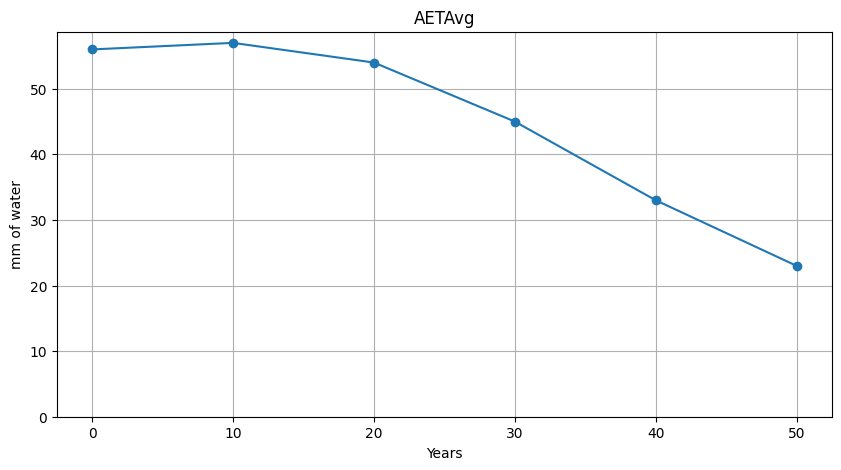

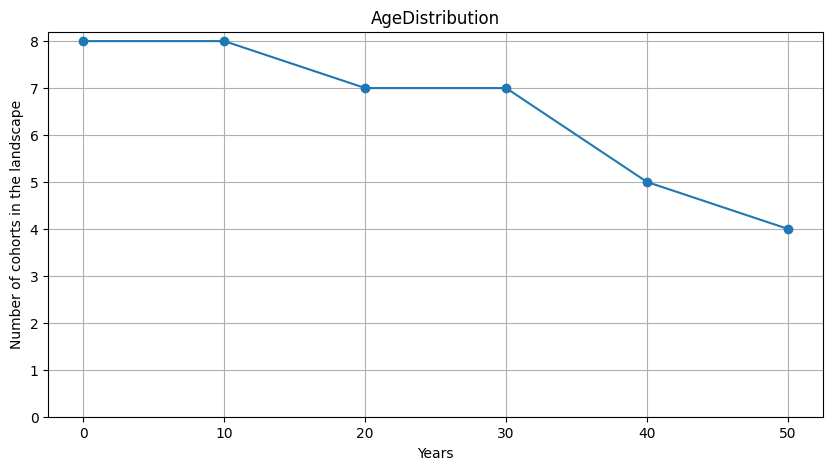

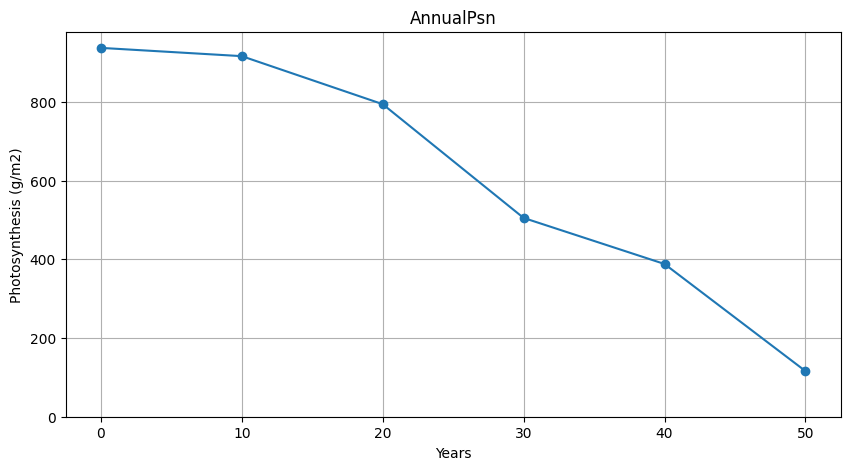

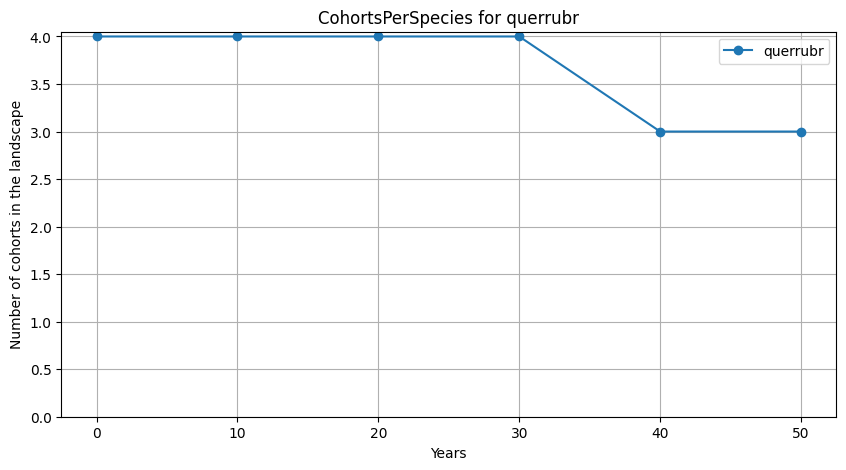

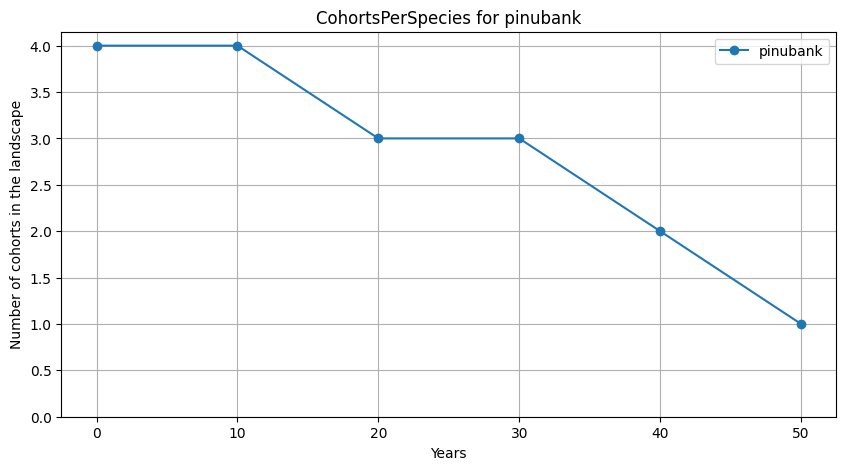

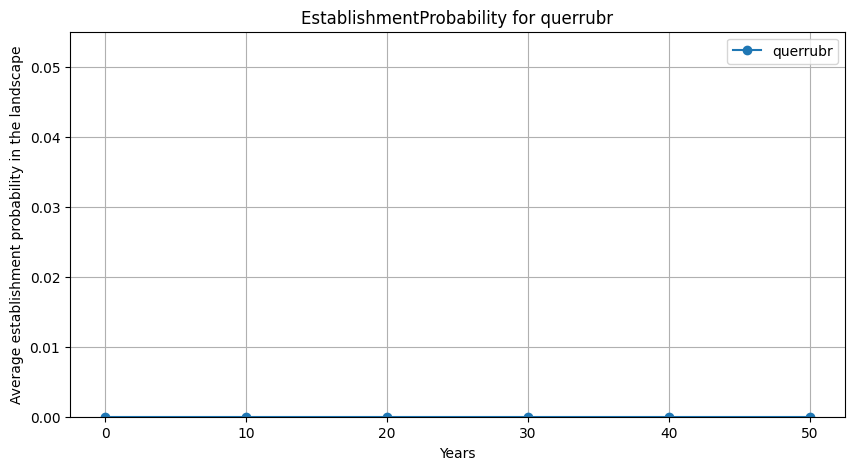

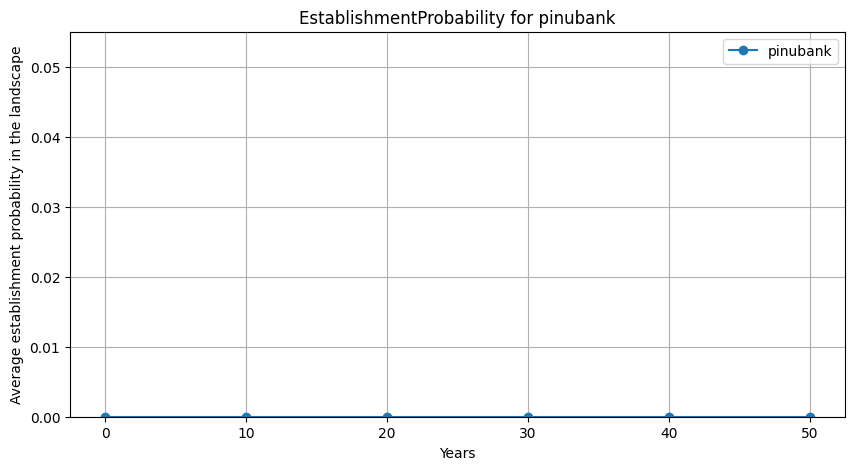

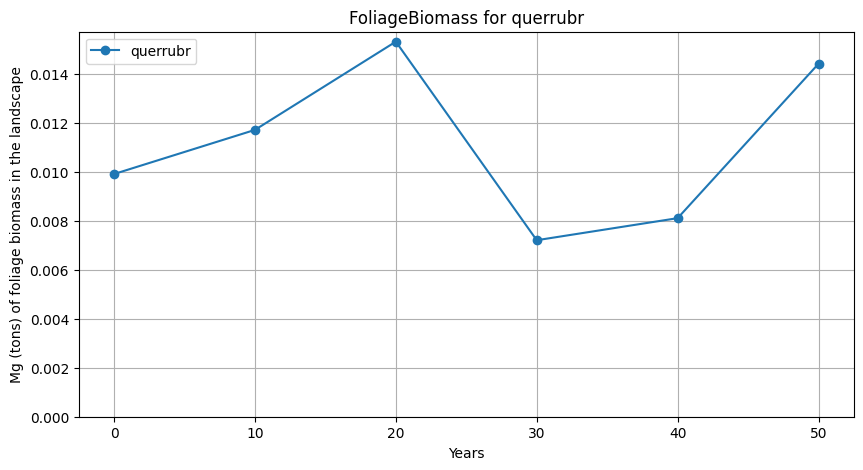

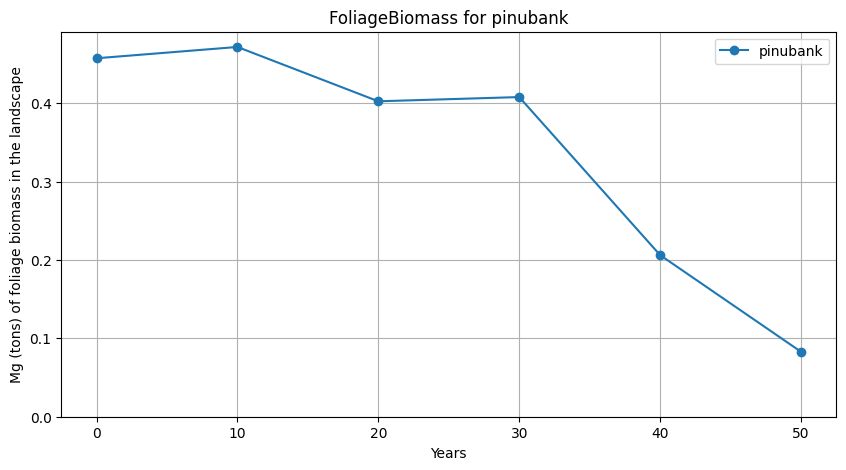

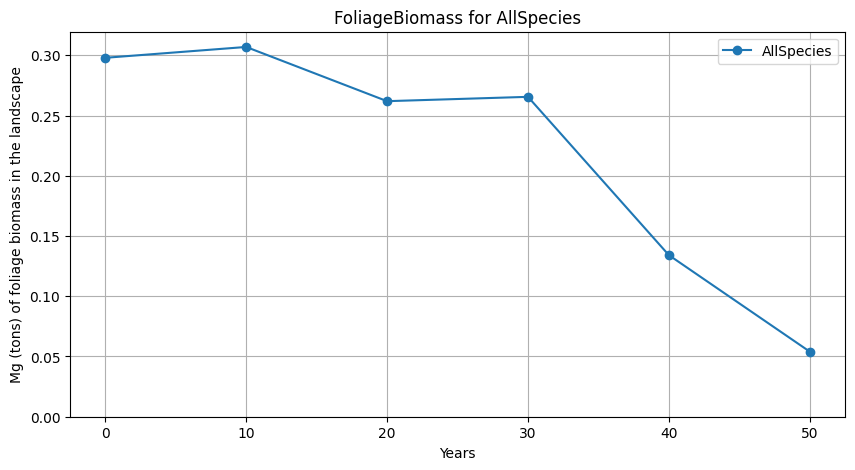

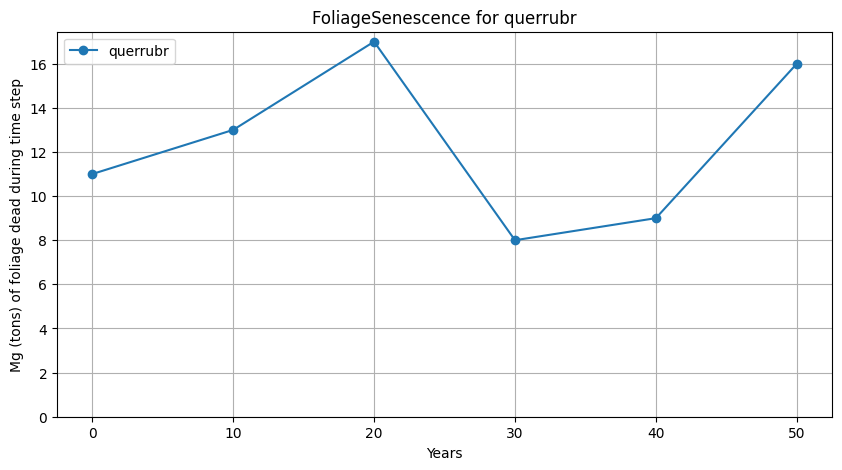

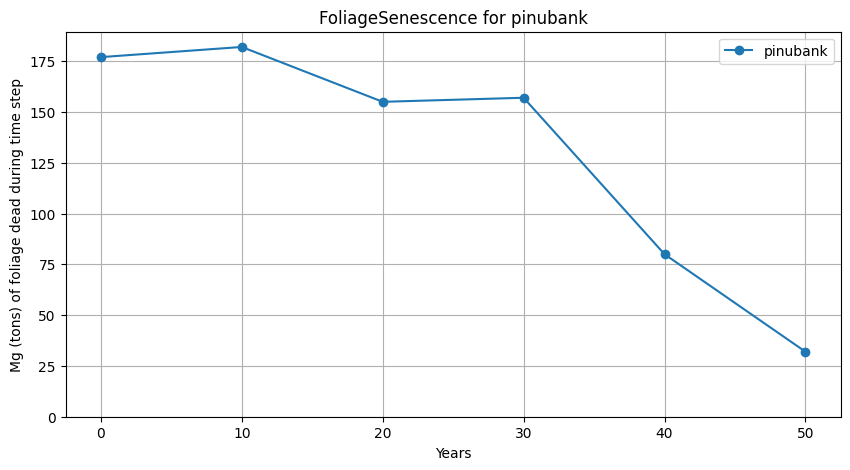

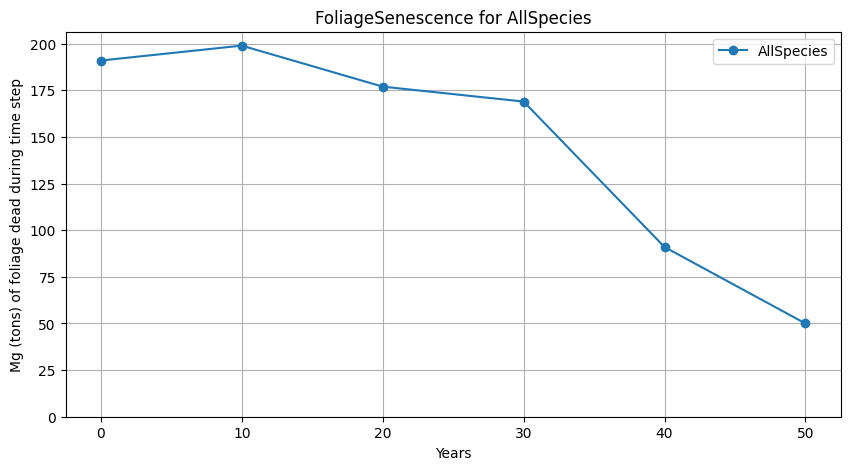

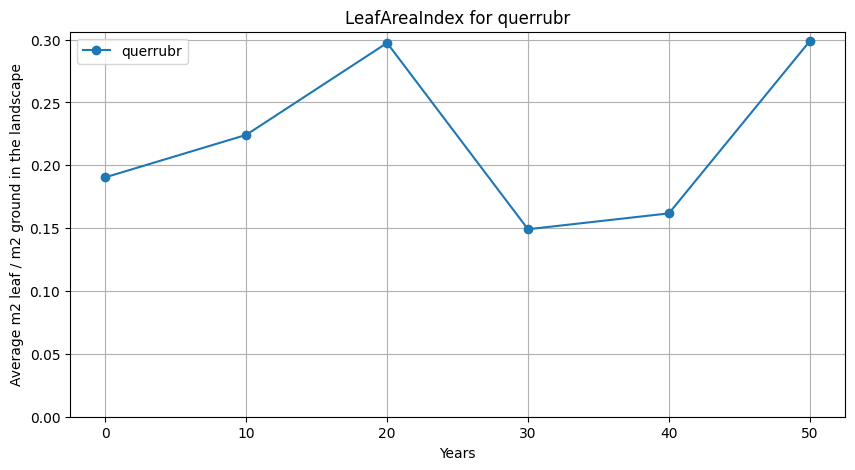

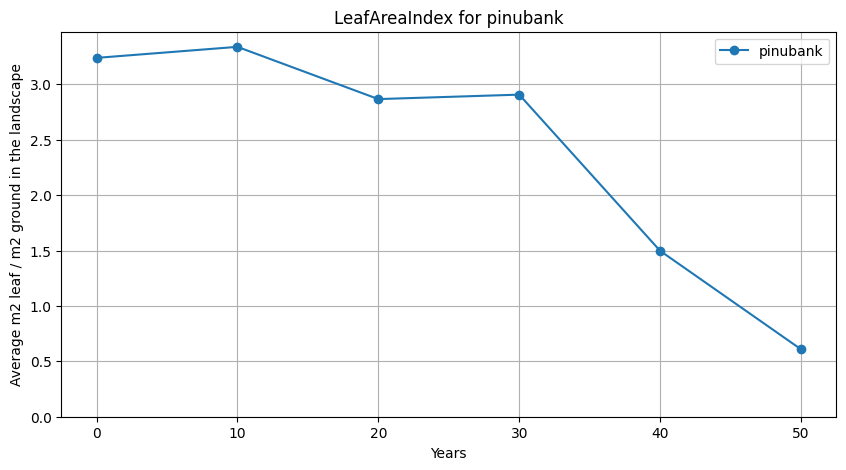

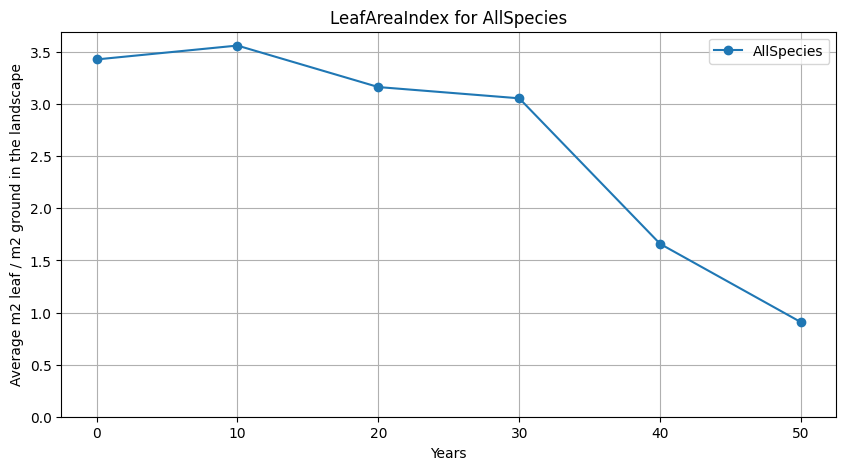

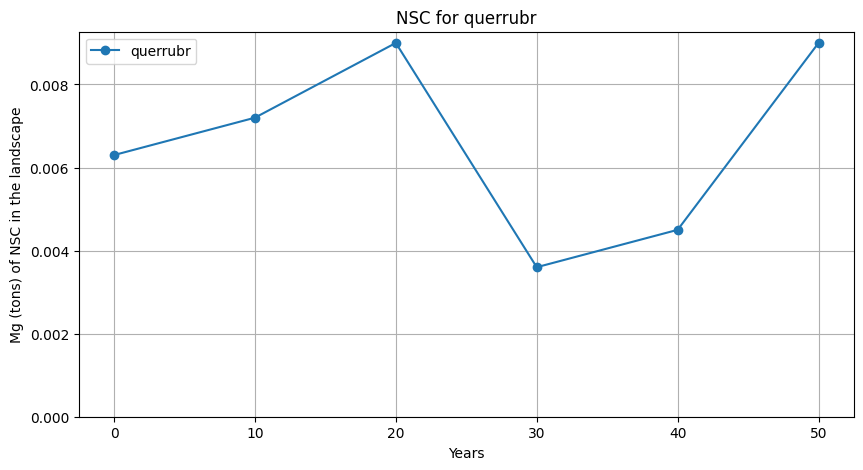

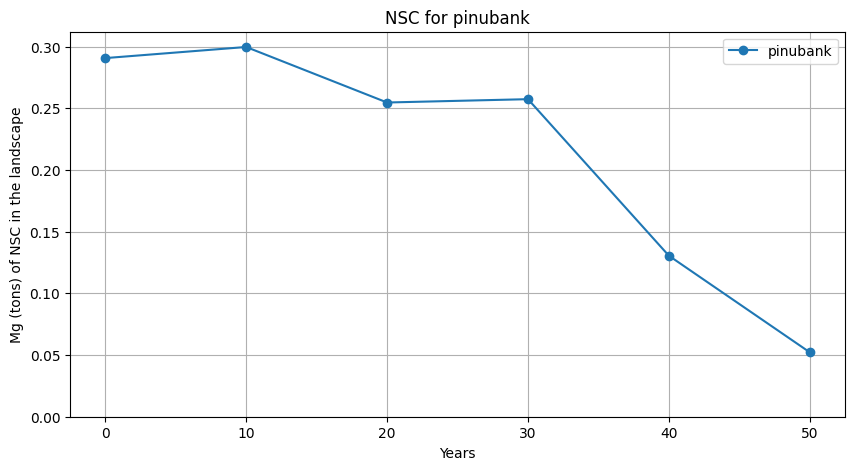

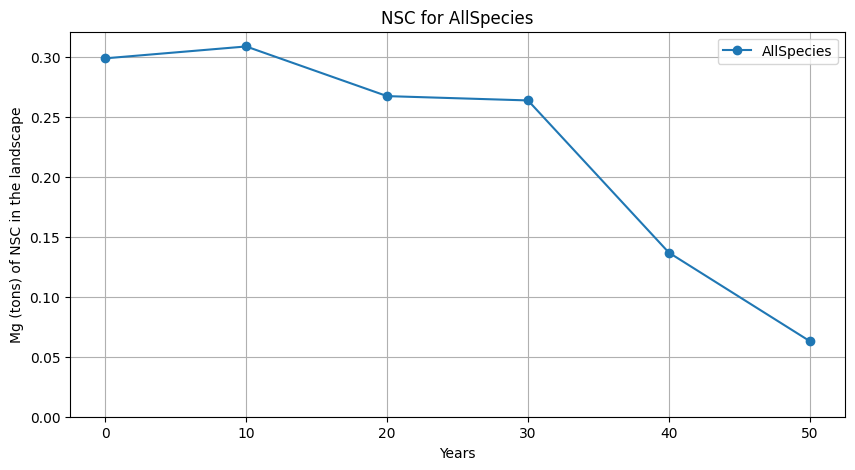

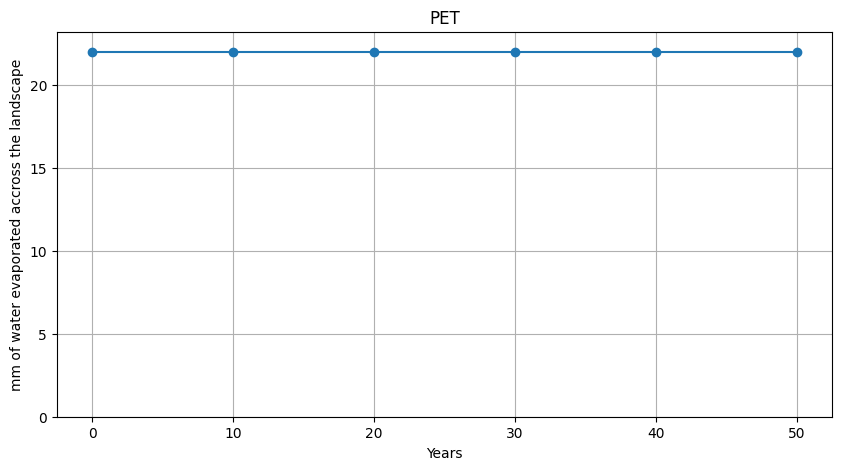

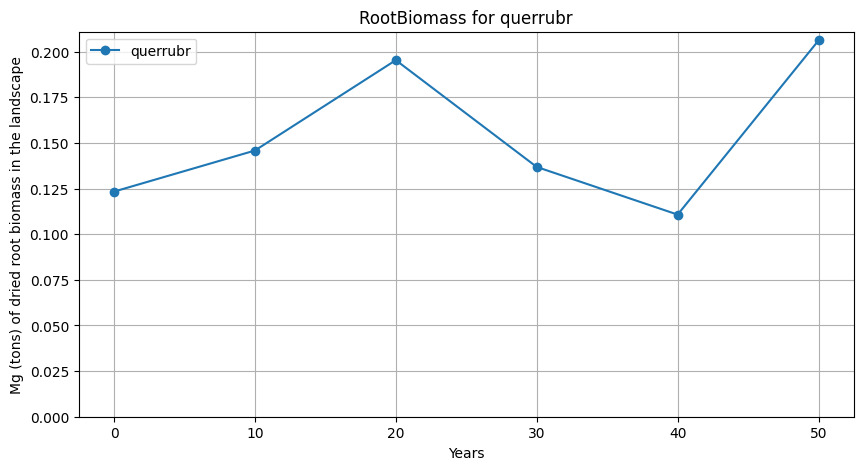

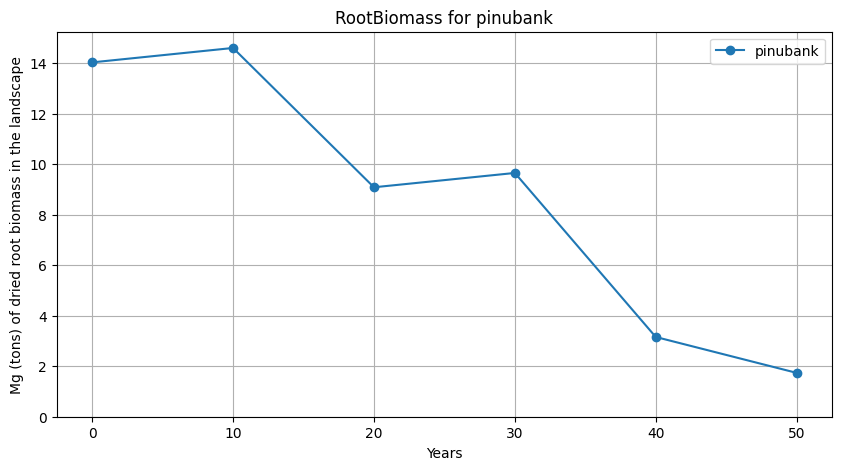

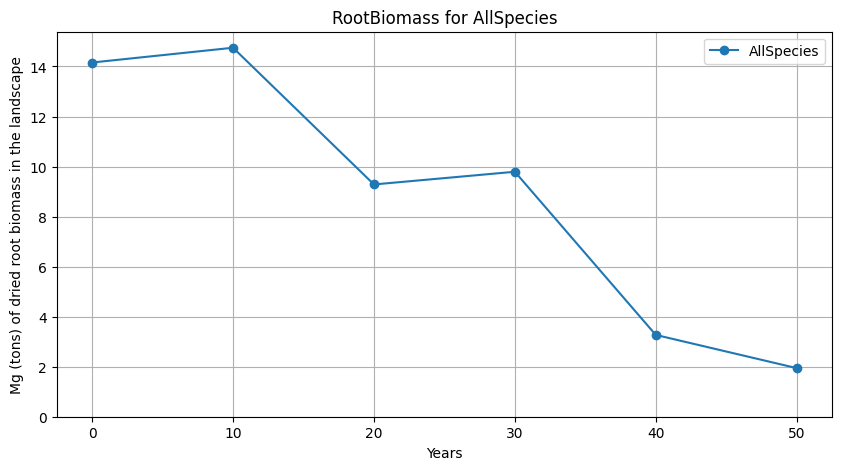

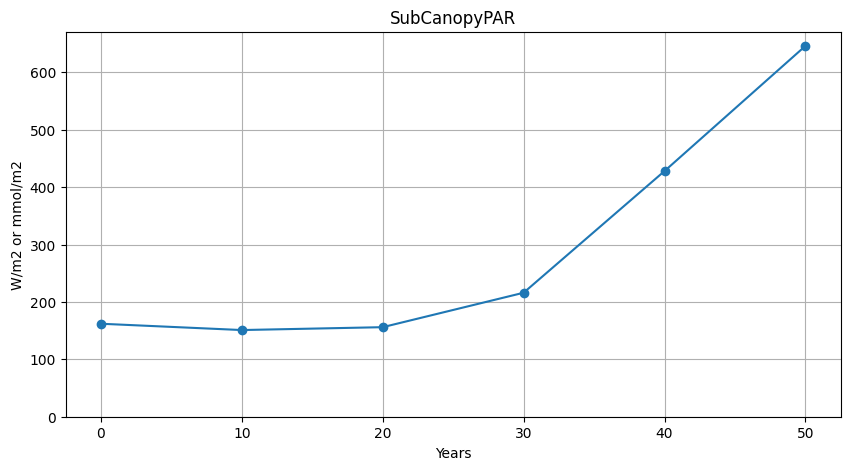

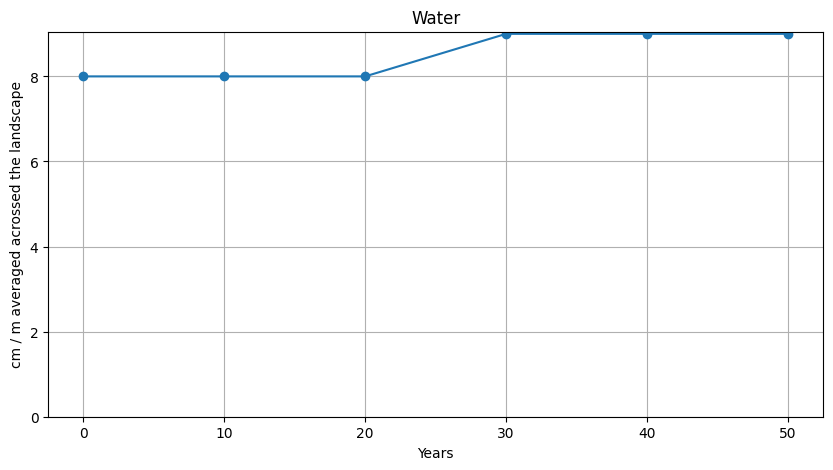

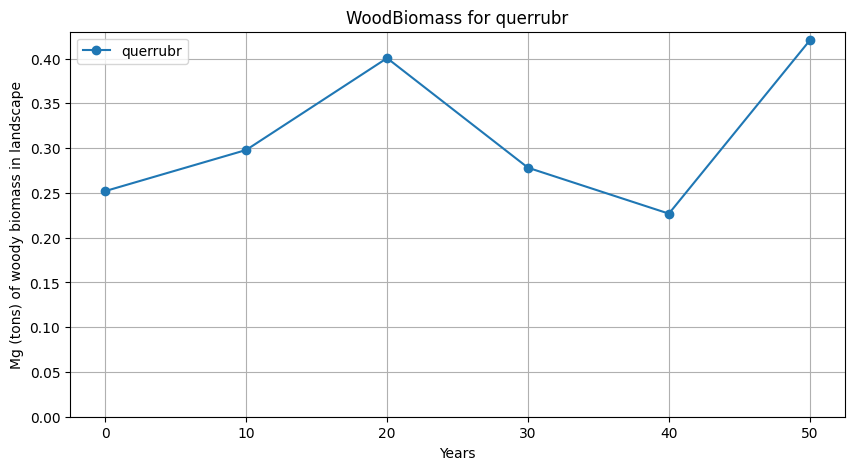

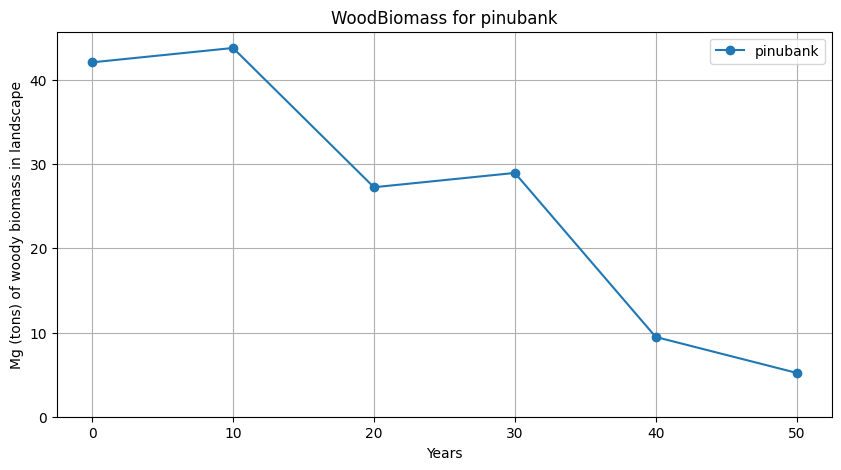

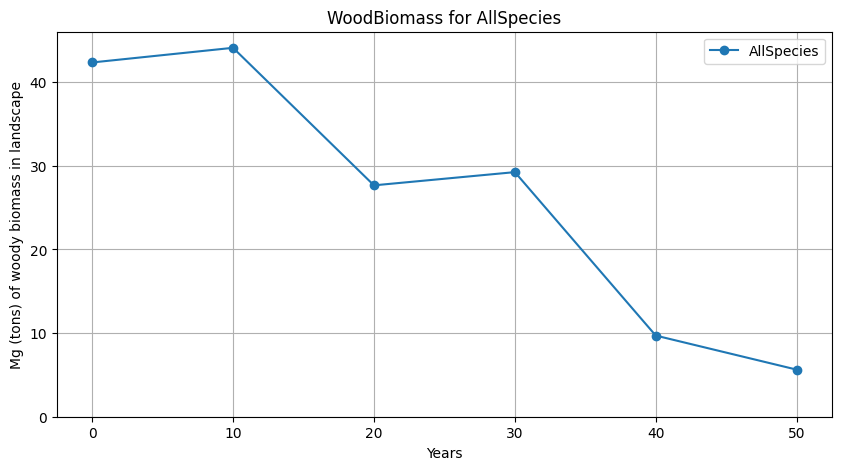

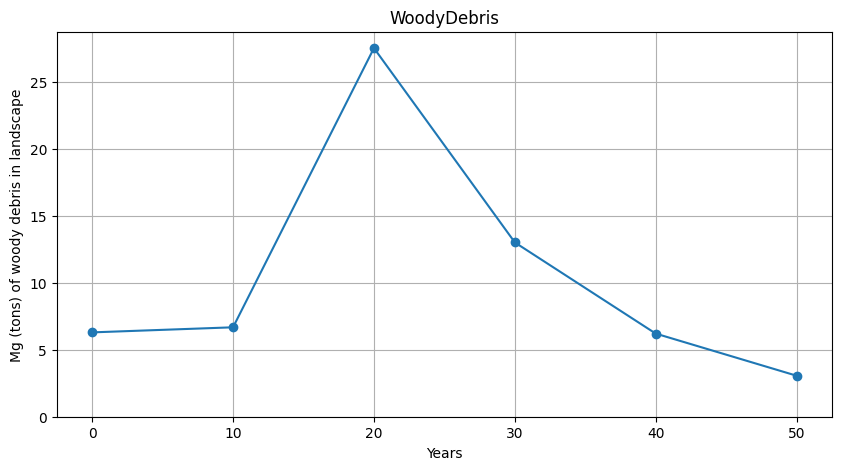

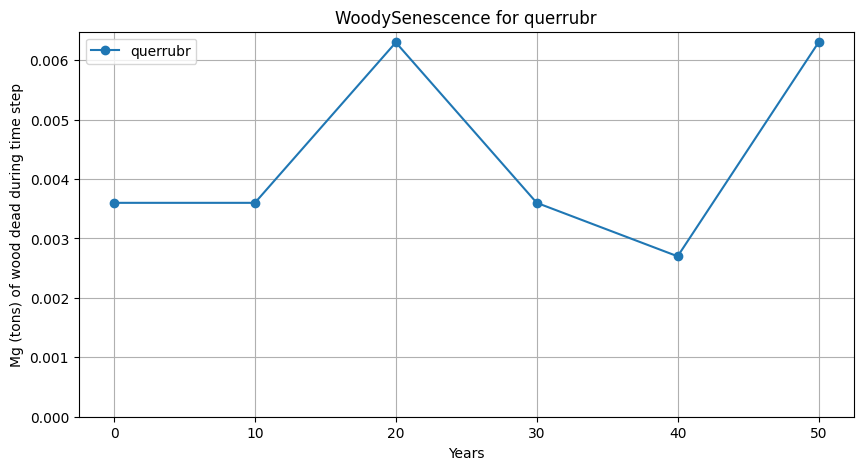

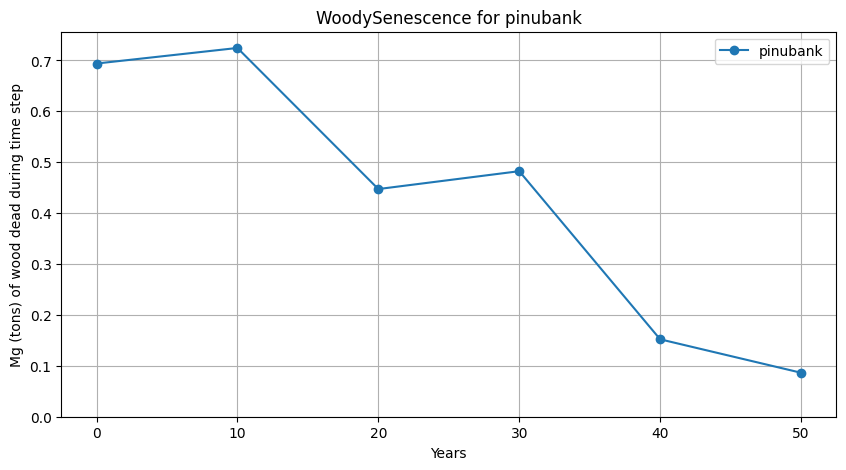

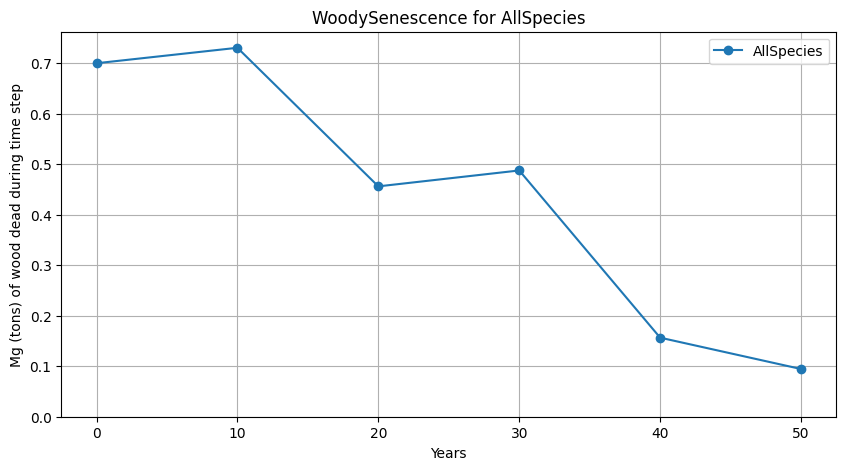

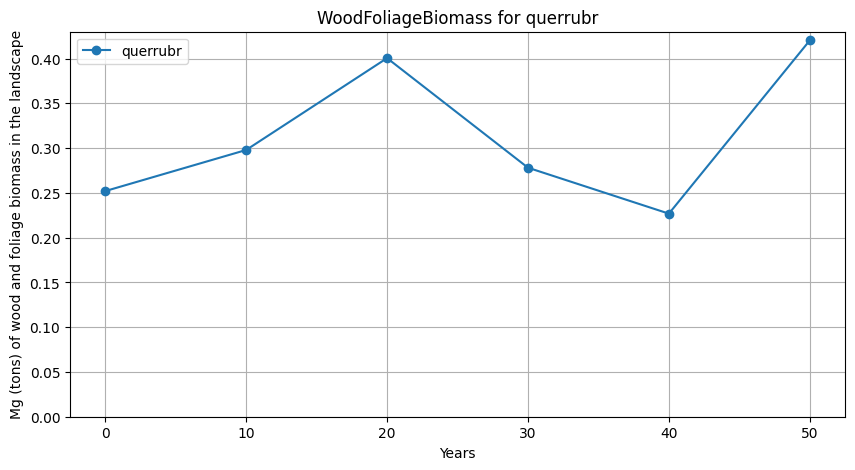

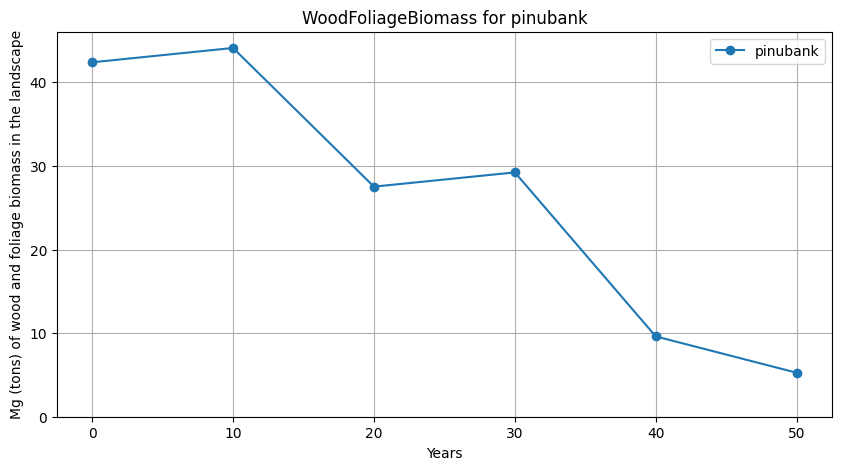

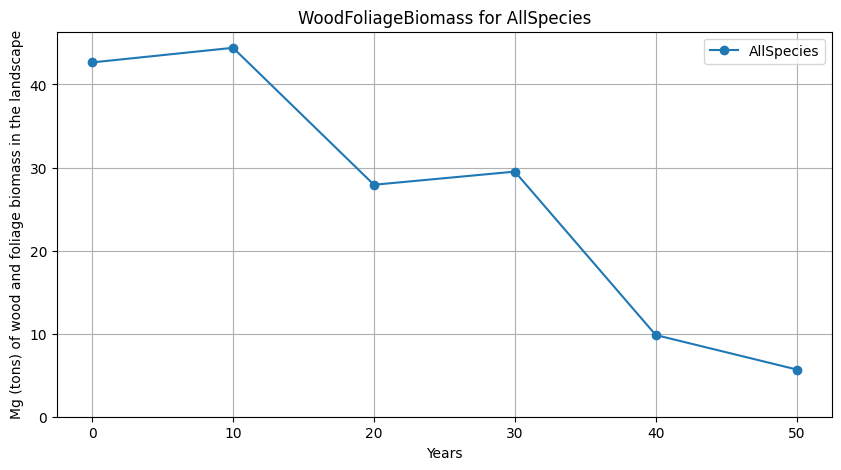

In [6]:
plot_TimeSeries_RasterPnETOutputs(result_Rasters,
                                  outputsUnitDict,
                                  int(PnETGitHub_OneCellSim["biomass.outputPnET.txt"]["Timestep"]),
                                  int(PnETGitHub_OneCellSim["scenario.txt"]["Duration"]))


## Plotting the content of the csv outputs from PnET Sites Output for one age cohort

All plots have been generated and saved.


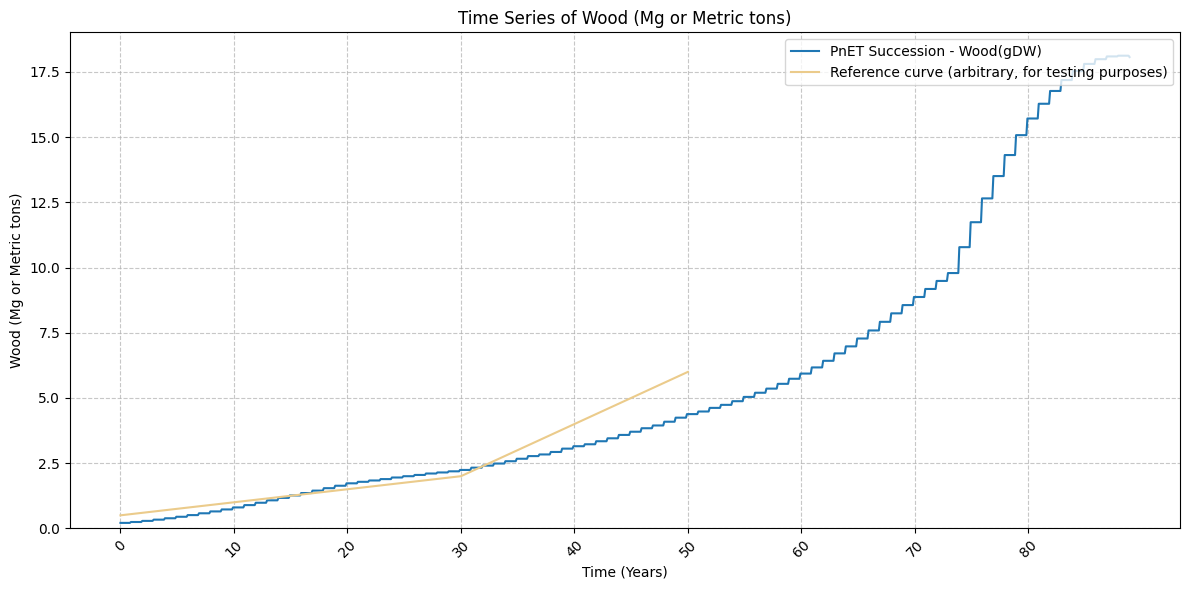

In [7]:
plot_TimeSeries_CSV_PnETSitesOutputs(list(result_sitesCSV.values())[0],
                                     referenceDict = {"Wood(gDW)":{"Time":[0, 10, 20, 30, 40, 50], "Values":[0.5, 1, 1.5, 2, 4, 6]}},
                                     columnToPlotSelector = ["Wood(gDW)"],
                                     trueTime = False,
                                     realBiomass = True,
                                     cellLength = int(PnETGitHub_OneCellSim["scenario.txt"]["CellLength"]),
                                     referenceLabel = "Reference curve (arbitrary, for testing purposes)")